# Chapter 37 — Polarisation & Faraday Rotation

!!! info "Before you start"
    **Prerequisites:** Ch 2, Ch 8 · **Maths Lab:** [Lab A (Fourier & Convolution)](31_mathslab_fourier_convolution.ipynb) · **~50 min** · **Intermediate**

---

Intensity is only half of what a radio wave carries.  Every coherent electromagnetic
wave also has a **polarisation state**: the direction in which its electric-field vector
oscillates.  In radio astronomy that fourth dimension — encoded in the **Stokes
parameters** $I, Q, U, V$ — opens up a completely different science channel: it probes
**cosmic magnetic fields** far too weak to detect any other way.

As a polarised wave travels through a magnetised plasma, its plane of oscillation
**rotates** — **Faraday rotation** — by an angle proportional to $\lambda^2$.  The
proportionality constant, the **Rotation Measure (RM)**, is an integral of the
electron density times the line-of-sight component of the magnetic field, making RM
observations a unique ruler for the magnetism of the ISM, CGM, and galaxy clusters.

> **Connection to Lab A.**  RM *synthesis* — the modern way to measure RMs from wide
> radio bands — is literally a one-dimensional Fourier transform in $\lambda^2$ space
> (Burn 1966; Brentjens & de Bruyn 2005).  If you are unsure about Fourier conventions,
> spend 20 minutes in [Lab A](31_mathslab_fourier_convolution.ipynb) before coming
> back.

### Learning goals

By the end of this chapter you will be able to:

- Define the **Stokes parameters** $I$, $Q$, $U$, $V$ and convert between them and the
  linear polarisation fraction $p$ and E-vector angle $\chi$.
- State and derive the **Faraday rotation law** $\chi(\lambda) = \chi_0 + \mathrm{RM}\,\lambda^2$
  and explain what the Rotation Measure probes physically.
- **Recover an RM two ways** from a synthetic polarised spectrum:
  (1) a least-squares fit of polarisation angle vs $\lambda^2$, and (2) RM synthesis /
  Faraday tomography, seeing both the Faraday dispersion function $|F(\phi)|$ and the
  RMSF ("dirty beam" in Faraday space).
- Connect these techniques to **cosmic-magnetism surveys** (POSSUM, LOFAR RM Grid, SKA)
  and understand why wide bands and many channels matter.


## The history and the papers

### Burn (1966) — the foundations of RM synthesis

> **Burn, B. J. (1966).**  *On the depolarization of discrete radio sources by
> Faraday dispersion.*  Monthly Notices of the Royal Astronomical Society **133**, 67.
> [ADS](https://ui.adsabs.harvard.edu/abs/1966MNRAS.133...67B)

Burn showed that a source embedded in (or behind) a *distribution* of magnetised gas
does not just rotate its polarisation angle — it **depolarises** it, because different
volumes along the line of sight have different Faraday depths $\phi$ and their
polarised contributions partially cancel.  He introduced what is now called the
**Faraday dispersion function** $F(\phi)$: the complex polarised surface brightness as a
function of Faraday depth.  The observed complex polarisation $P(\lambda^2)$ and the
Faraday dispersion function $F(\phi)$ are a **Fourier-transform pair** in $\lambda^2$:

$$
P(\lambda^2) = \int_{-\infty}^{+\infty} F(\phi)\,e^{2i\phi\lambda^2}\,\mathrm{d}\phi,
\qquad
F(\phi) = \int_{-\infty}^{+\infty} P(\lambda^2)\,e^{-2i\phi\lambda^2}\,\mathrm{d}\lambda^2.
$$

This is the theoretical seed that germinated fully four decades later, once wideband
receivers made it possible to sample $P(\lambda^2)$ densely enough to recover $F(\phi)$
from real data.

### Brentjens & de Bruyn (2005) — RM synthesis in practice

> **Brentjens, M. A. & de Bruyn, A. G. (2005).**  *Faraday rotation measure synthesis.*
> Astronomy & Astrophysics **441**, 1217.
> [DOI](https://doi.org/10.1051/0004-6361:20052990) · [ADS](https://ui.adsabs.harvard.edu/abs/2005A%26A...441.1217B)

Brentjens & de Bruyn made the Burn integral *computable* from radio data.  Because we
observe only a finite, discretely sampled range of $\lambda^2$ values, the true Faraday
dispersion function can only be *approximated* by a **weighted sum** over channels:

$$
\tilde{F}(\phi) \approx K \sum_{i=1}^{N} w_i\,P(\lambda_i^2)\,e^{-2i\phi(\lambda_i^2 - \lambda_0^2)}.
$$

They defined the **Rotation Measure Spread Function (RMSF)** — the response of this
sum to a single point-source at one Faraday depth — as the Faraday analogue of the
interferometric dirty beam.  Its width sets the Faraday-depth **resolution**, and
deconvolution (RM-CLEAN) can recover overlapping Faraday components just as CLEAN
recovers point sources.

### Dreher, Carilli & Perley (1987) — Faraday rotation in Cygnus A

> **Dreher, J. W., Carilli, C. L. & Perley, R. A. (1987).**  *The Faraday Rotation
> of Cygnus A: Magnetic Fields in Cluster Gas.*  The Astrophysical Journal **316**, 611.
> [ADS](https://ui.adsabs.harvard.edu/abs/1987ApJ...316..611D)  *(also in the
> [Papers Timeline](../docs/papers-timeline.md))*

Using the VLA in full polarisation mode across four frequencies, Dreher et al. mapped the
RM across the Cygnus A radio lobes and hotspots.  They found RMs up to $\sim 4000\,\mathrm{rad\,m^{-2}}$
— far too large for the diffuse ISM alone — proving that the intracluster medium of the
Cygnus cluster hosts a **tangled magnetic field** of order $\sim 10\text{–}40\,\mu\mathrm{G}$,
compressed and amplified by the passage of the radio jets.  This was the first systematic
RM map of a powerful radio galaxy.

### Garrington et al. (1988) — the Laing–Garrington effect

> **Garrington, S. T., Leahy, J. P., Conway, R. G. & Laing, R. A. (1988).**
> *A Systematic Asymmetry in the Polarization Properties of Double Radio Sources with
> One Jet.*  Nature **331**, 147.  [ADS](https://ui.adsabs.harvard.edu/abs/1988Natur.331..147G)
> *(also in the [Papers Timeline](../docs/papers-timeline.md))*

Garrington et al. discovered that in **double radio sources** the lobe on the
**jet side** always has *lower* depolarisation than the counter-jet lobe.  The
explanation is elegant: the approaching jet is **Doppler-boosted** and therefore seen
more face-on, so its lobe sits *closer to us* and therefore behind *less* Faraday-rotating
magnetoionic material.  This **Laing–Garrington effect** became a clean proof that the jets
are relativistic, and that environment — not source structure — drives the depolarisation
asymmetry.


## The physics

### Stokes parameters

A quasi-monochromatic electromagnetic wave propagating along $\hat{z}$ has electric-field
components $(E_x, E_y)$.  The four **Stokes parameters** — measurable, real quantities —
characterise every possible polarisation state:

$$
\begin{aligned}
I &= \langle|E_x|^2\rangle + \langle|E_y|^2\rangle & &\text{(total intensity)}\\
Q &= \langle|E_x|^2\rangle - \langle|E_y|^2\rangle & &\text{(linear: } x\text{- vs }y\text{-preference)}\\
U &= 2\,\mathrm{Re}\langle E_x E_y^*\rangle          & &\text{(linear: }45°\text{ vs }135°\text{ preference)}\\
V &= 2\,\mathrm{Im}\langle E_x E_y^*\rangle          & &\text{(circular polarisation)}\\
\end{aligned}
$$

with the **energy inequality** $I^2 \geq Q^2 + U^2 + V^2$.  For a purely linearly
polarised wave with total intensity $I$ and polarisation fraction $p$:

$$
Q = p\,I\cos 2\chi, \qquad U = p\,I\sin 2\chi,
$$

where $\chi$ is the **E-vector position angle** (measured N through E).  The factor of
2 reflects the fact that polarisation is a headless vector: rotating by $\pi$ returns
the same state.  The **complex linear polarisation** $P = Q + iU = p\,I\,e^{2i\chi}$
packages $Q$ and $U$ elegantly into a single phasor.

### Faraday rotation

A linearly polarised wave traversing a magnetised plasma experiences a different
**phase velocity** for its two circular components.  The net effect is a rotation of
$\chi$ by

$$
\boxed{\Delta\chi = \mathrm{RM}\cdot\lambda^2},
$$

so the observed polarisation angle is

$$
\chi(\lambda) = \chi_0 + \mathrm{RM}\cdot\lambda^2,
$$

where the **Rotation Measure** is a line-of-sight integral:

$$
\mathrm{RM} = \frac{e^3}{2\pi m_e^2 c^4}\int_0^d n_e\,B_\parallel\,\mathrm{d}l
\;\approx\; 0.812 \int_0^d \frac{n_e}{\mathrm{cm}^{-3}}\frac{B_\parallel}{\mu\mathrm{G}}\frac{\mathrm{d}l}{\mathrm{pc}}\;\;\mathrm{rad\,m^{-2}}.
$$

Here $n_e$ is the free-electron number density and $B_\parallel$ is the **line-of-sight
component of the magnetic field** (positive = towards the observer).  Even a field as
weak as $1\,\mu\mathrm{G}$ integrated over $1\,\mathrm{kpc}$ of ionised gas with
$n_e \sim 0.03\,\mathrm{cm}^{-3}$ produces $|\mathrm{RM}| \sim 25\,\mathrm{rad\,m^{-2}}$
— easily detectable across a modern wideband receiver.

> **Key insight:** RM is the only direct measure of the **line-of-sight average** of
> $n_e B_\parallel$.  Combined with a Dispersion Measure (DM, see Ch 13), you can
> separate $\langle B_\parallel \rangle$ from $n_e$.

### RM synthesis as a Fourier transform (Burn 1966; Brentjens & de Bruyn 2005)

For a **Faraday-thin screen** (all emission at a single Faraday depth $\phi_0$):

$$
P(\lambda^2) = p\,I\,e^{2i(\chi_0 + \phi_0\lambda^2)},
$$

so the Faraday dispersion function $F(\phi) \propto \delta(\phi - \phi_0)$: a spike at
$\phi_0 = \mathrm{RM}$.  For a distribution of screens along the line of sight:

$$
P(\lambda^2) = \int_{-\infty}^{+\infty} F(\phi)\,e^{2i\phi\lambda^2}\,\mathrm{d}\phi.
$$

This is a **Fourier transform** with conjugate variable pair $(\lambda^2, \phi)$.  We
measure $P$ at discrete $\lambda_i^2$ over a finite range, so the best we can do is the
**RM synthesis** estimator:

$$
\tilde{F}(\phi) = K\sum_{i=1}^N w_i\,P(\lambda_i^2)\,e^{-2i\phi(\lambda_i^2 - \lambda_0^2)},
$$

where $\lambda_0^2 = \sum w_i\lambda_i^2 / \sum w_i$ is the weighted mean $\lambda^2$,
chosen to minimise spurious phase gradients.  The corresponding **RMSF** is

$$
R(\phi) = K\sum_{i=1}^N w_i\,e^{-2i\phi(\lambda_i^2 - \lambda_0^2)},
$$

the Faraday dirty beam.  Its **FWHM** sets the Faraday-depth resolution:

$$
\delta\phi \approx \frac{2\sqrt{3}}{\Delta\lambda^2},
$$

and the **maximum detectable Faraday depth** (before bandwidth depolarisation kills a thin
screen within a single channel) is $\phi_{\max} \approx \sqrt{3}/\delta\lambda^2$, where
$\delta\lambda^2$ is the per-channel $\lambda^2$ width.


## Setup

We use the `jansky.polarization` module for all polarisation and Faraday calculations,
`astropy.constants` and `astropy.units` for physical constants (never hard-coded), and
`jansky.signals.rng` for reproducible noise.  `plotting.use_jansky_style()` applies the
course-wide figure style.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u

from jansky import polarization, plotting
from jansky.polarization import (
    stokes_linear,
    linear_polarization_fraction,
    polarization_angle,
    complex_polarization,
    faraday_rotate,
    rotation_measure_fit,
    rmsf,
    rm_synthesis,
)
from jansky.signals import rng as make_rng
from jansky.plotting import use_jansky_style

use_jansky_style()

# One reproducible random generator for the whole chapter.
rng = make_rng(37)

# Speed of light from astropy — never hard-coded.
c_mps = const.c.to(u.m / u.s).value  # m/s
print(f"c = {c_mps:.6e} m/s  (from astropy.constants)")
print("jansky.polarization API:", polarization.__all__)

c = 2.997925e+08 m/s  (from astropy.constants)
jansky.polarization API: ['stokes_linear', 'linear_polarization_fraction', 'polarization_angle', 'complex_polarization', 'faraday_rotate', 'rotation_measure_fit', 'rmsf', 'rm_synthesis']


## Stokes parameters, polarisation fraction, and E-vector angle

Before we do any Faraday physics, let us make sure we can go back and forth between
$(I, p, \chi)$ and $(Q, U)$.  The `jansky.polarization` helpers implement both directions.


In [2]:
# --- A single example first ---
I_total = 1.0  # normalised total intensity
p_frac = 0.35  # 35 % linearly polarised
chi_0 = np.deg2rad(30.0)  # E-vector at 30 degrees

Q, U = stokes_linear(I_total, p_frac, chi_0)
print(f"Q = {Q:.4f}   U = {U:.4f}")

# Round-trip: recover p and chi from Q and U.
p_rec = linear_polarization_fraction(I_total, Q, U)
chi_rec = polarization_angle(Q, U)

print(f"Recovered:  p = {p_rec:.4f}  (input {p_frac})")
print(f"Recovered:  χ = {np.rad2deg(chi_rec):.2f} deg  (input {np.rad2deg(chi_0):.2f} deg)")
print(f"Complex polarisation P = {complex_polarization(Q, U):.4f}")

Q = 0.1750   U = 0.3031
Recovered:  p = 0.3500  (input 0.35)
Recovered:  χ = 30.00 deg  (input 30.00 deg)
Complex polarisation P = 0.1750+0.3031j


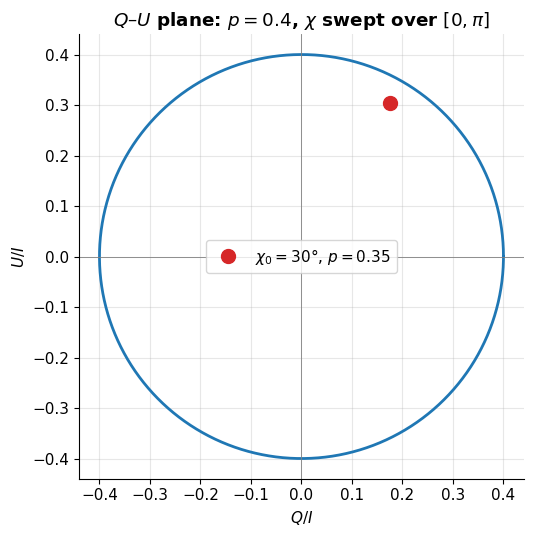

Each point on the circle corresponds to a different E-vector orientation χ.
A full rotation of χ by π traverses the circle once (factor-of-2 geometry).


In [3]:
# --- Visualise the Poincaré-sphere slice (Q–U plane) ---
# Vary χ from 0 to π (a full rotation of the polarisation state) with fixed p.
chi_arr = np.linspace(0, np.pi, 360)
Q_arr, U_arr = stokes_linear(1.0, 0.4, chi_arr)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(Q_arr, U_arr, color="#1f77b4", lw=2)
ax.plot(Q, U, "o", ms=10, color="#d62728", label=r"$\chi_0 = 30°$, $p = 0.35$")
ax.axhline(0, color="grey", lw=0.6)
ax.axvline(0, color="grey", lw=0.6)
ax.set_xlabel(r"$Q / I$")
ax.set_ylabel(r"$U / I$")
ax.set_title(r"$Q$–$U$ plane: $p = 0.4$, $\chi$ swept over $[0, \pi]$")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()
print("Each point on the circle corresponds to a different E-vector orientation χ.")
print("A full rotation of χ by π traverses the circle once (factor-of-2 geometry).")

## Building a realistic wideband polarised spectrum

We simulate an ASKAP/POSSUM-like observation: 700–1800 MHz with 256 channels.
Converting frequency $\nu$ to wavelength $\lambda = c/\nu$ (and $\lambda^2$) is the
key step — Faraday rotation is linear in $\lambda^2$, *not* in $\nu$.


In [4]:
# ASKAP/POSSUM-like band: 700–1800 MHz, 256 channels.
nu_min_MHz = 700.0
nu_max_MHz = 1800.0
n_chan = 256

freq_hz = np.linspace(nu_min_MHz, nu_max_MHz, n_chan) * 1e6  # Hz
lam_m = c_mps / freq_hz  # wavelengths in metres
lam2_m2 = lam_m**2  # λ² in m²

print(f"Band:     {nu_min_MHz:.0f} – {nu_max_MHz:.0f} MHz  ({n_chan} channels)")
print(f"λ range:  {lam_m.min():.3f} – {lam_m.max():.3f} m")
print(f"λ² range: {lam2_m2.min():.4f} – {lam2_m2.max():.4f} m²")
print(
    f"Δλ²  =  {lam2_m2.max() - lam2_m2.min():.4f} m²"
    f"  →  δφ ≈ {2 * np.sqrt(3) / (lam2_m2.max() - lam2_m2.min()):.1f} rad/m²"
)

Band:     700 – 1800 MHz  (256 channels)
λ range:  0.167 – 0.428 m
λ² range: 0.0277 – 0.1834 m²
Δλ²  =  0.1557 m²  →  δφ ≈ 22.3 rad/m²


## Example 1 — Noiseless Faraday-rotated spectrum

We inject a known rotation measure (RM = +50 rad/m²) and intrinsic angle
($\chi_0 = 20°$), then build $Q(\nu)$ and $U(\nu)$ spectra.  The oscillations in
$Q$ and $U$ are the signature of Faraday rotation: the shorter the $\lambda$ (higher
the frequency), the slower the rotation rate per channel.


In [5]:
# Injected source parameters.
RM_true = 50.0  # rad/m²
chi0_deg = 20.0  # intrinsic E-vector angle, degrees
chi0_rad = np.deg2rad(chi0_deg)
I_source = 1.0  # normalised total intensity (flat spectrum)
p_source = 0.30  # 30 % linearly polarised

# Apply Faraday rotation: χ(λ) = χ₀ + RM·λ²
chi_lambda = faraday_rotate(chi0_rad, RM_true, lam_m)

# Build Q and U spectra.
Q_spec, U_spec = stokes_linear(I_source, p_source, chi_lambda)

# Complex polarisation phasor P(λ²) = Q + iU.
P_spec = complex_polarization(Q_spec, U_spec)

print(f"Injected RM    = {RM_true}  rad/m²")
print(f"Injected χ₀   = {chi0_deg}°")
print(f"Max |P|       = {np.abs(P_spec).max():.4f}  (should equal p × I = {p_source * I_source})")

Injected RM    = 50.0  rad/m²
Injected χ₀   = 20.0°
Max |P|       = 0.3000  (should equal p × I = 0.3)


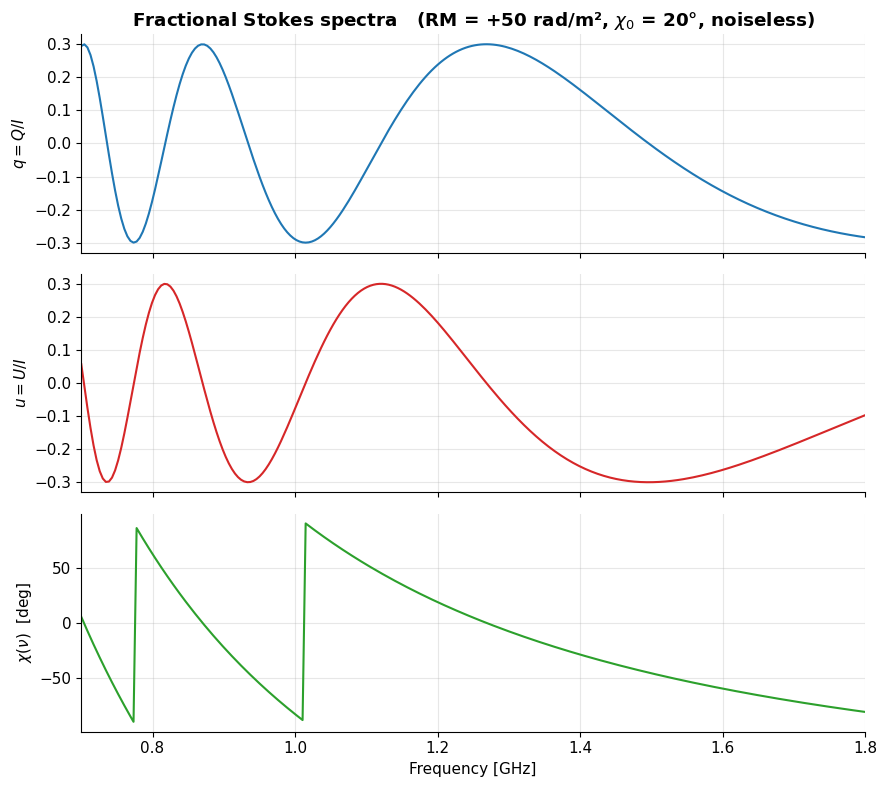

In [6]:
# Figure: Q/U fractional spectra vs frequency.
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(freq_hz / 1e9, Q_spec / I_source, color="#1f77b4", lw=1.5)
axes[0].set_ylabel(r"$q = Q/I$")
axes[0].set_title(r"Fractional Stokes spectra   (RM = +50 rad/m², $\chi_0$ = 20°, noiseless)")

axes[1].plot(freq_hz / 1e9, U_spec / I_source, color="#d62728", lw=1.5)
axes[1].set_ylabel(r"$u = U/I$")

axes[2].plot(freq_hz / 1e9, np.rad2deg(polarization_angle(Q_spec, U_spec)), color="#2ca02c", lw=1.5)
axes[2].set_ylabel(r"$\chi(\nu)$  [deg]")
axes[2].set_xlabel("Frequency [GHz]")

for ax in axes:
    ax.set_xlim(freq_hz.min() / 1e9, freq_hz.max() / 1e9)

plt.tight_layout()
plt.show()

## Recovering the RM — Method 1: least-squares fit of $\chi$ vs $\lambda^2$

The simplest RM estimator: plot the observed polarisation angle $\chi$ against
$\lambda^2$ and fit a straight line.  The slope is RM, the intercept is $\chi_0$.

The `rotation_measure_fit` helper unwraps the $\pi$-periodic angle $2\chi$ before
fitting, reducing (but not fully eliminating) the $n\pi$ ambiguity that plagues
sparse-frequency measurements.


In [7]:
# Fit χ(λ) vs λ² — noiseless case.
chi_obs = polarization_angle(Q_spec, U_spec)
RM_fit, chi0_fit = rotation_measure_fit(lam_m, chi_obs)

print(f"Least-squares fit:")
print(f"  RM_fit  = {RM_fit:.3f}  rad/m²  (injected: {RM_true})")
print(f"  χ₀_fit  = {np.rad2deg(chi0_fit):.2f}°  (injected: {chi0_deg}°)")
print(f"  ΔRM     = {abs(RM_fit - RM_true):.2e}  rad/m²")

Least-squares fit:
  RM_fit  = 50.000  rad/m²  (injected: 50.0)
  χ₀_fit  = -160.00°  (injected: 20.0°)
  ΔRM     = 1.42e-14  rad/m²


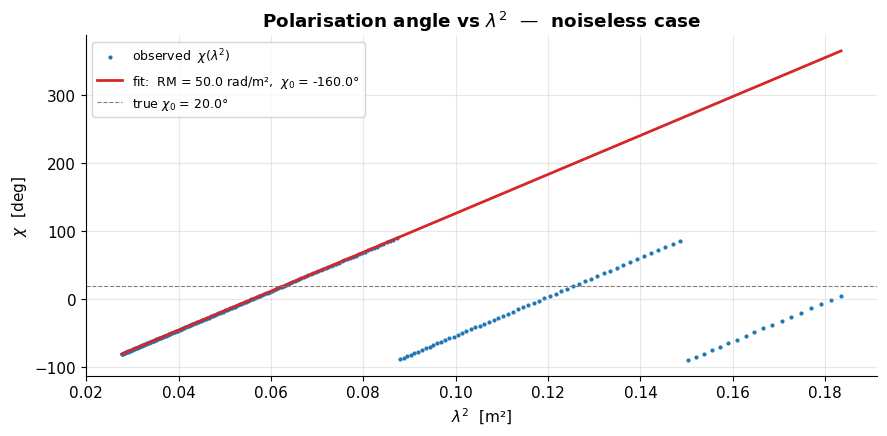

In [8]:
# Plot: polarisation angle vs λ²  with the fitted line.
lam2_plot = np.linspace(lam2_m2.min(), lam2_m2.max(), 400)
chi_model = chi0_fit + RM_fit * lam2_plot  # fitted line

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(
    lam2_m2,
    np.rad2deg(chi_obs),
    s=4,
    color="#1f77b4",
    label="observed  $\\chi(\\lambda^2)$",
    rasterized=True,
)
ax.plot(
    lam2_plot,
    np.rad2deg(chi_model),
    color="#d62728",
    lw=2,
    label=rf"fit:  RM = {RM_fit:.1f} rad/m²,  $\chi_0$ = {np.rad2deg(chi0_fit):.1f}°",
)
ax.axhline(chi0_deg, color="grey", ls="--", lw=0.8, label=rf"true $\chi_0$ = {chi0_deg}°")
ax.set_xlabel(r"$\lambda^2$  [m²]")
ax.set_ylabel(r"$\chi$  [deg]")
ax.set_title(r"Polarisation angle vs $\lambda^2$  —  noiseless case")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Recovering the RM — Method 2: RM synthesis (Brentjens & de Bruyn 2005)

RM synthesis computes the **Faraday dispersion function** $F(\phi)$: the Fourier
transform of $P(\lambda^2)$ from the observed $\lambda^2$ sampling.  For a
Faraday-thin source, $|F(\phi)|$ peaks at $\phi = \mathrm{RM}$.

The **RMSF** (Rotation Measure Spread Function) is the Faraday dirty beam — the
response to a single delta-function at $\phi = 0$.  Its width is the Faraday-depth
resolution; its sidelobes set the dynamic range.


In [9]:
# Faraday-depth axis: range ±800 rad/m², step 1 rad/m².
phi_arr = np.arange(-800.0, 801.0, 1.0)  # rad/m²

# RM synthesis: Faraday dispersion function F(φ).
F_phi = rm_synthesis(lam_m, P_spec, phi_arr)

# RMSF: the Faraday dirty beam R(φ).
R_phi = rmsf(lam_m, phi_arr)

# Peak of |F(φ)| → recovered RM.
peak_idx = np.argmax(np.abs(F_phi))
RM_rmsyn = phi_arr[peak_idx]

print(f"RM synthesis peak at  φ = {RM_rmsyn:.1f}  rad/m²  (injected: {RM_true})")
print(f"|F|_peak = {np.abs(F_phi[peak_idx]):.4f}  (should ≈ {p_source * I_source:.4f})")
print(
    f"RMSF width ≈ {2 * np.sqrt(3) / (lam2_m2.max() - lam2_m2.min()):.1f} rad/m²  (theoretical δφ)"
)

RM synthesis peak at  φ = 50.0  rad/m²  (injected: 50.0)
|F|_peak = 0.3000  (should ≈ 0.3000)
RMSF width ≈ 22.3 rad/m²  (theoretical δφ)


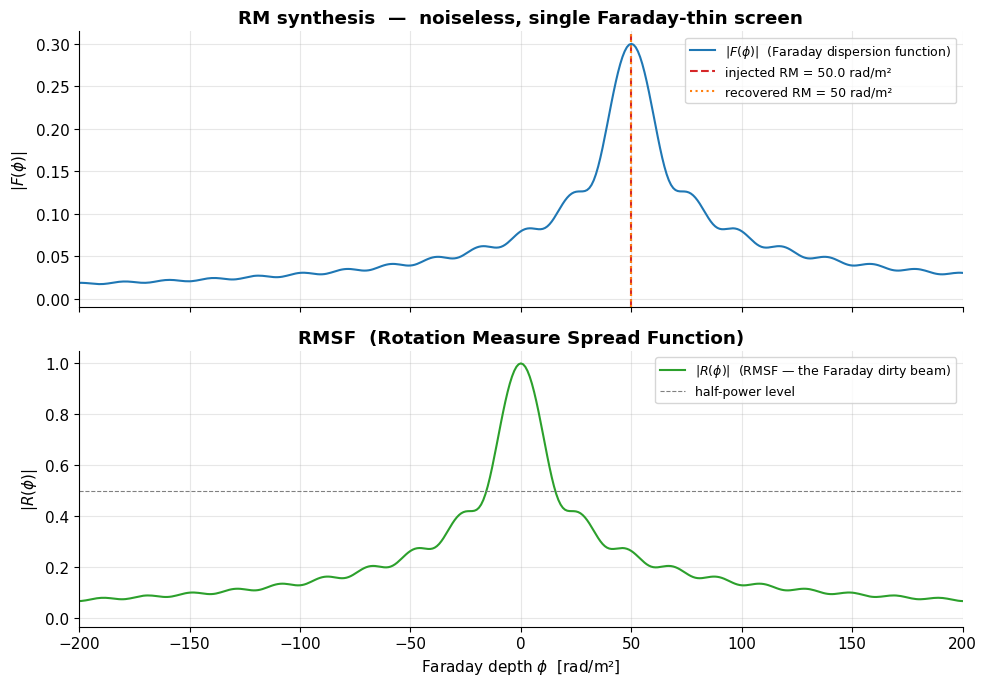

In [10]:
# Figure A: |F(φ)| and the RMSF — noiseless case.
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    phi_arr,
    np.abs(F_phi),
    color="#1f77b4",
    lw=1.5,
    label=r"$|F(\phi)|$  (Faraday dispersion function)",
)
axes[0].axvline(RM_true, color="#d62728", ls="--", lw=1.5, label=rf"injected RM = {RM_true} rad/m²")
axes[0].axvline(
    RM_rmsyn, color="#ff7f0e", ls=":", lw=1.5, label=rf"recovered RM = {RM_rmsyn:.0f} rad/m²"
)
axes[0].set_ylabel(r"$|F(\phi)|$")
axes[0].set_title("RM synthesis  —  noiseless, single Faraday-thin screen")
axes[0].legend(fontsize=9)

axes[1].plot(
    phi_arr,
    np.abs(R_phi),
    color="#2ca02c",
    lw=1.5,
    label=r"$|R(\phi)|$  (RMSF — the Faraday dirty beam)",
)
axes[1].axhline(0.5, color="grey", ls="--", lw=0.8, label="half-power level")
axes[1].set_ylabel(r"$|R(\phi)|$")
axes[1].set_xlabel(r"Faraday depth $\phi$  [rad/m²]")
axes[1].set_title("RMSF  (Rotation Measure Spread Function)")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlim(-200, 200)

plt.tight_layout()
plt.show()

## Example 2 — Recovering an RM from a noisy spectrum

Real observations have noise.  We add Gaussian noise to $Q$ and $U$ independently
(the realistic case: each is measured in a separate correlator product), representing
a modest signal-to-noise ratio in polarised intensity.  Both methods are still able to
recover the RM accurately.


In [11]:
# Add Gaussian noise to Q and U independently.
noise_sigma = 0.04  # ~ SNR ≈ p·I / noise_sigma ≈ 0.30/0.04 = 7.5 per channel

Q_noisy = Q_spec + rng.normal(0.0, noise_sigma, size=n_chan)
U_noisy = U_spec + rng.normal(0.0, noise_sigma, size=n_chan)
P_noisy = complex_polarization(Q_noisy, U_noisy)

# Check polarised SNR in the band.
pI_noisy = np.abs(P_noisy)
print(f"Mean |P| (noisy) = {pI_noisy.mean():.4f}  (true {p_source * I_source:.4f})")
print(f"Per-channel noise σ = {noise_sigma};  per-channel SNR ≈ {p_source / noise_sigma:.1f}")

Mean |P| (noisy) = 0.3023  (true 0.3000)
Per-channel noise σ = 0.04;  per-channel SNR ≈ 7.5


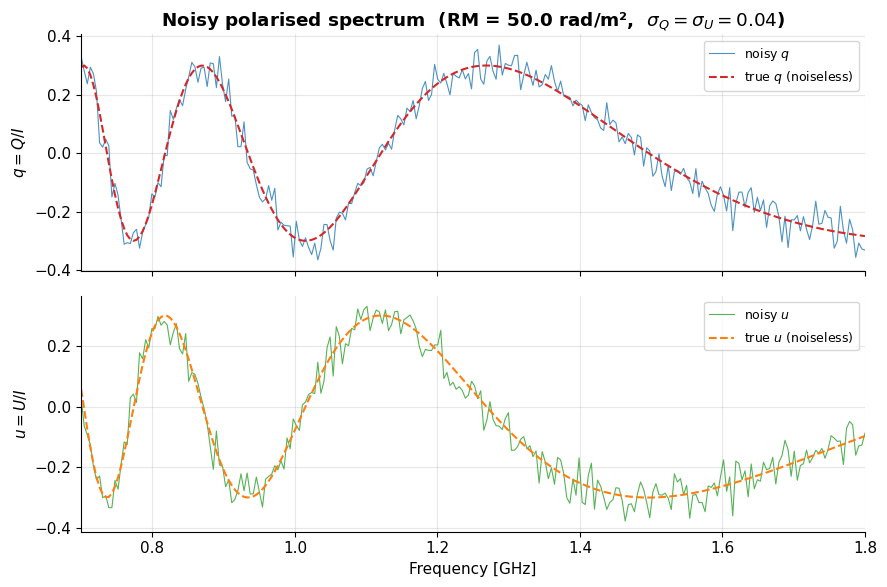

In [12]:
# Figure: noisy q, u spectra vs frequency.
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(
    freq_hz / 1e9, Q_noisy / I_source, color="#1f77b4", lw=0.8, alpha=0.8, label="noisy $q$"
)
axes[0].plot(
    freq_hz / 1e9, Q_spec / I_source, color="#d62728", lw=1.5, ls="--", label="true $q$ (noiseless)"
)
axes[0].set_ylabel(r"$q = Q/I$")
axes[0].set_title(
    rf"Noisy polarised spectrum  (RM = {RM_true} rad/m²,  $\sigma_Q = \sigma_U = {noise_sigma}$)"
)
axes[0].legend(fontsize=9)

axes[1].plot(
    freq_hz / 1e9, U_noisy / I_source, color="#2ca02c", lw=0.8, alpha=0.8, label="noisy $u$"
)
axes[1].plot(
    freq_hz / 1e9, U_spec / I_source, color="#ff7f0e", lw=1.5, ls="--", label="true $u$ (noiseless)"
)
axes[1].set_ylabel(r"$u = U/I$")
axes[1].set_xlabel("Frequency [GHz]")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlim(freq_hz.min() / 1e9, freq_hz.max() / 1e9)

plt.tight_layout()
plt.show()

In [13]:
# Method 1 on noisy data: χ vs λ² fit.
chi_noisy = polarization_angle(Q_noisy, U_noisy)
RM_fit_n, chi0_fit_n = rotation_measure_fit(lam_m, chi_noisy)

print(f"Least-squares fit (noisy):")
print(f"  RM_fit  = {RM_fit_n:.2f}  rad/m²  (true: {RM_true})")
print(f"  χ₀_fit  = {np.rad2deg(chi0_fit_n):.2f}°  (true: {chi0_deg}°)")

Least-squares fit (noisy):
  RM_fit  = 49.92  rad/m²  (true: 50.0)
  χ₀_fit  = -160.19°  (true: 20.0°)


In [14]:
# Method 2 on noisy data: RM synthesis.
F_noisy = rm_synthesis(lam_m, P_noisy, phi_arr)
peak_n = np.argmax(np.abs(F_noisy))
RM_rms_n = phi_arr[peak_n]

print(f"RM synthesis (noisy):  φ_peak = {RM_rms_n:.1f}  rad/m²  (true: {RM_true})")

# Noise floor in |F| — std of wings far from the source.
wings = np.abs(F_noisy[np.abs(phi_arr) > 300])
noise_floor = wings.std()
print(
    f"Noise floor in |F|:  {noise_floor:.4f}  (peak SNR ≈ {np.abs(F_noisy[peak_n]) / noise_floor:.1f})"
)

RM synthesis (noisy):  φ_peak = 50.0  rad/m²  (true: 50.0)
Noise floor in |F|:  0.0038  (peak SNR ≈ 78.6)


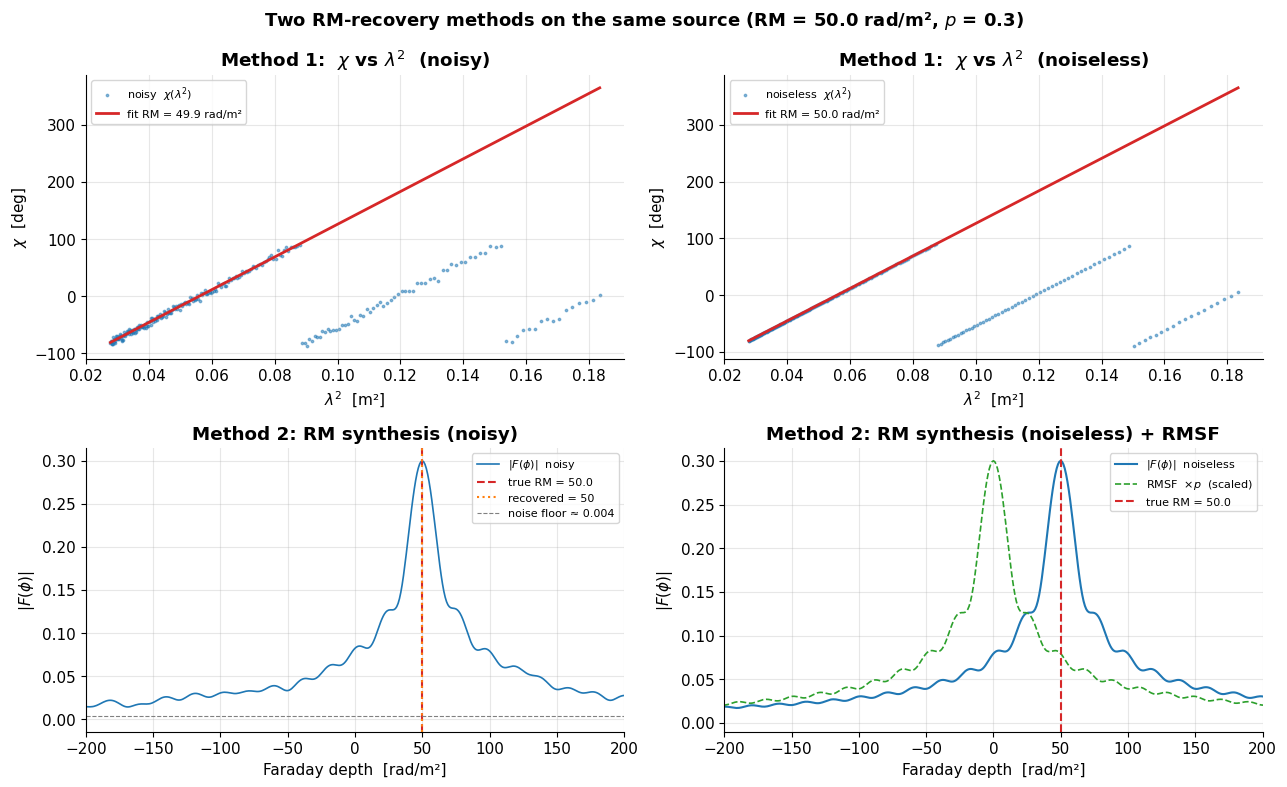


Summary:
  True RM           = 50.0  rad/m²
  χ-fit (noiseless) = 50.00  rad/m²
  χ-fit (noisy)     = 49.92  rad/m²
  RM synthesis (nl) = 50.0  rad/m²
  RM synthesis (n)  = 50.0  rad/m²


In [15]:
# Figure B: noisy RM synthesis vs noiseless — 4-panel comparison.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Top-left: χ vs λ² — noisy + fit.
chi_model_n = chi0_fit_n + RM_fit_n * lam2_plot
axes[0, 0].scatter(
    lam2_m2,
    np.rad2deg(chi_noisy),
    s=3,
    color="#1f77b4",
    alpha=0.5,
    rasterized=True,
    label="noisy  $\\chi(\\lambda^2)$",
)
axes[0, 0].plot(
    lam2_plot,
    np.rad2deg(chi_model_n),
    color="#d62728",
    lw=2,
    label=rf"fit RM = {RM_fit_n:.1f} rad/m²",
)
axes[0, 0].set_xlabel(r"$\lambda^2$  [m²]")
axes[0, 0].set_ylabel(r"$\chi$  [deg]")
axes[0, 0].set_title(r"Method 1:  $\chi$ vs $\lambda^2$  (noisy)")
axes[0, 0].legend(fontsize=8)

# Top-right: χ vs λ² — noiseless.
axes[0, 1].scatter(
    lam2_m2,
    np.rad2deg(chi_obs),
    s=3,
    color="#1f77b4",
    alpha=0.5,
    rasterized=True,
    label="noiseless  $\\chi(\\lambda^2)$",
)
axes[0, 1].plot(
    lam2_plot, np.rad2deg(chi_model), color="#d62728", lw=2, label=rf"fit RM = {RM_fit:.1f} rad/m²"
)
axes[0, 1].set_xlabel(r"$\lambda^2$  [m²]")
axes[0, 1].set_ylabel(r"$\chi$  [deg]")
axes[0, 1].set_title(r"Method 1:  $\chi$ vs $\lambda^2$  (noiseless)")
axes[0, 1].legend(fontsize=8)

# Bottom-left: |F(φ)| — noisy.
axes[1, 0].plot(phi_arr, np.abs(F_noisy), color="#1f77b4", lw=1.2, label=r"$|F(\phi)|$  noisy")
axes[1, 0].axvline(RM_true, color="#d62728", ls="--", lw=1.5, label=rf"true RM = {RM_true}")
axes[1, 0].axvline(RM_rms_n, color="#ff7f0e", ls=":", lw=1.5, label=rf"recovered = {RM_rms_n:.0f}")
axes[1, 0].axhline(
    noise_floor, color="grey", ls="--", lw=0.8, label=rf"noise floor ≈ {noise_floor:.3f}"
)
axes[1, 0].set_xlim(-200, 200)
axes[1, 0].set_xlabel(r"Faraday depth  [rad/m²]")
axes[1, 0].set_ylabel(r"$|F(\phi)|$")
axes[1, 0].set_title("Method 2: RM synthesis (noisy)")
axes[1, 0].legend(fontsize=8)

# Bottom-right: |F(φ)| — noiseless + RMSF.
axes[1, 1].plot(phi_arr, np.abs(F_phi), color="#1f77b4", lw=1.5, label=r"$|F(\phi)|$  noiseless")
axes[1, 1].plot(
    phi_arr,
    np.abs(R_phi) * p_source,
    color="#2ca02c",
    lw=1.2,
    ls="--",
    label=r"RMSF  $\times p$  (scaled)",
)
axes[1, 1].axvline(RM_true, color="#d62728", ls="--", lw=1.5, label=rf"true RM = {RM_true}")
axes[1, 1].set_xlim(-200, 200)
axes[1, 1].set_xlabel(r"Faraday depth  [rad/m²]")
axes[1, 1].set_ylabel(r"$|F(\phi)|$")
axes[1, 1].set_title("Method 2: RM synthesis (noiseless) + RMSF")
axes[1, 1].legend(fontsize=8)

fig.suptitle(
    rf"Two RM-recovery methods on the same source (RM = {RM_true} rad/m², $p$ = {p_source})",
    fontsize=13,
    weight="bold",
)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  True RM           = {RM_true:.1f}  rad/m²")
print(f"  χ-fit (noiseless) = {RM_fit:.2f}  rad/m²")
print(f"  χ-fit (noisy)     = {RM_fit_n:.2f}  rad/m²")
print(f"  RM synthesis (nl) = {RM_rmsyn:.1f}  rad/m²")
print(f"  RM synthesis (n)  = {RM_rms_n:.1f}  rad/m²")

## The RMSF — the Faraday dirty beam

The RMSF (Rotation Measure Spread Function) plays exactly the same role in Faraday
space as the dirty beam does in image space (Ch 8–9): it is the instrumental response,
set entirely by the $\lambda^2$ sampling, and its width determines the resolution.

Below we show how the RMSF changes with the band choice, demonstrating the key trade-offs:

- **Wider band** (larger $\Delta\lambda^2$) → **finer Faraday-depth resolution** (narrower RMSF).
- **Lower frequencies** → **larger maximum $\lambda^2$** → access to larger Faraday depths.


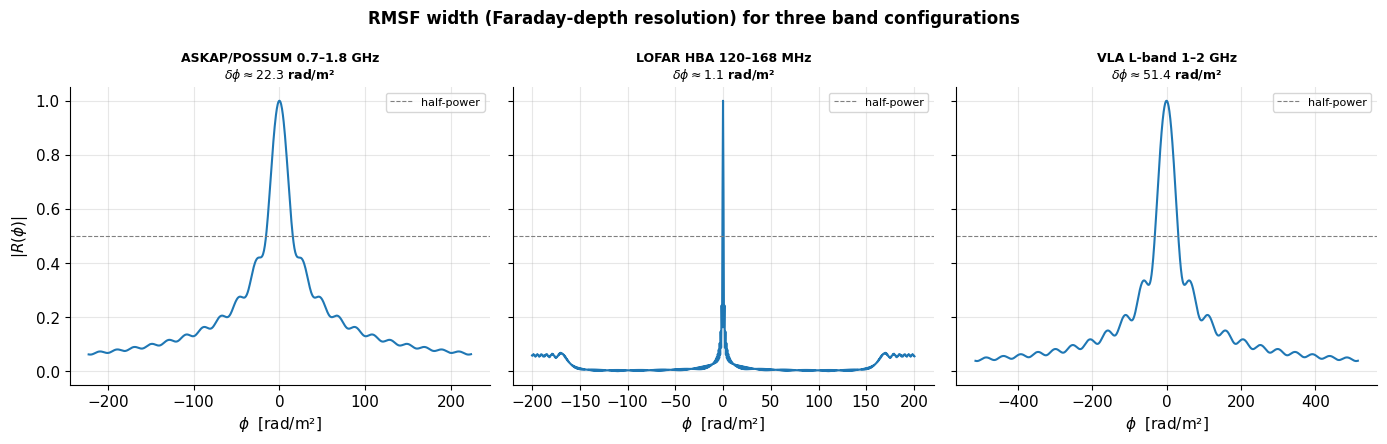

In [16]:
# Compare RMSFs for three different band configurations.
configs = {
    "ASKAP/POSSUM 0.7–1.8 GHz": (700e6, 1800e6, 256),
    "LOFAR HBA 120–168 MHz": (120e6, 168e6, 256),
    "VLA L-band 1–2 GHz": (1000e6, 2000e6, 256),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (label, (f_lo, f_hi, nc)) in zip(axes, configs.items()):
    f_arr = np.linspace(f_lo, f_hi, nc)
    lam_arr = c_mps / f_arr
    l2_arr = lam_arr**2
    delta_l2 = l2_arr.max() - l2_arr.min()
    delta_phi = 2 * np.sqrt(3) / delta_l2

    phi_range = max(10 * delta_phi, 200.0)  # generous range to show sidelobes
    phi_local = np.arange(-phi_range, phi_range + 1.0, 0.5)
    R_local = rmsf(lam_arr, phi_local)

    ax.plot(phi_local, np.abs(R_local), lw=1.5)
    ax.axhline(0.5, color="grey", ls="--", lw=0.8, label="half-power")
    ax.set_xlabel(r"$\phi$  [rad/m²]")
    ax.set_title(
        f"{label}\n"
        rf"$\delta\phi \approx {delta_phi:.1f}$ rad/m²",
        fontsize=9,
    )
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|R(\phi)|$")
fig.suptitle(
    "RMSF width (Faraday-depth resolution) for three band configurations",
    fontsize=12,
    weight="bold",
)
plt.tight_layout()
plt.show()

## Cosmic magnetism: RM grids and the big picture

Rotation measures encode the **line-of-sight magnetic field** averaged over whatever
ionised gas lies between us and the source.  A single RM is interesting; *a million RMs*
across the sky map the three-dimensional magnetism of the entire Galaxy and beyond.

### Typical RM values

| Environment                          | $|\mathrm{RM}|$ range        |
|--------------------------------------|------------------------------|
| High-latitude Galactic ISM           | $1$–$50$ rad/m²              |
| Galactic plane / HII regions         | $100$–$1000$ rad/m²          |
| Cluster intracluster medium (e.g. Cygnus A) | $100$–$4000$ rad/m²   |
| Extragalactic (cosmological)         | $\lesssim 5$ rad/m²          |

The Dreher et al. (1987) Cygnus A RM map reached values up to $\sim 4000$ rad/m²,
proving dense, magnetised intracluster gas.  The Laing–Garrington (1988) asymmetry
then confirmed that environment — not source structure — drives the pattern.

### RM Grid surveys

The real power of RM synthesis is **statistical**: you measure RMs towards many
background polarised sources per square degree, turning the sky into a grid of
line-of-sight probes.

| Survey | Telescope | Resolution | Density | Status |
|--------|-----------|-----------|---------|--------|
| NVSS RM Catalog (Taylor et al. 2009) | VLA | ~45 arcsec | ~1.2/deg² | Complete |
| LOFAR RM Grid (O'Sullivan et al. 2023, LoTSS-DR2) | LOFAR | ~20 arcsec | ~0.4/deg² | Ongoing |
| POSSUM (Gaensler et al.) | ASKAP | ~10 arcsec | ~25–40/deg² | Ongoing |
| SKA-Mid Band 2 RM Grid | SKA | ~0.5 arcsec | ~300–1000/deg² | 2030s |

POSSUM alone is expected to deliver of order $\sim 10^6$ RM measurements across the
Southern sky, enabling **tomographic reconstruction** of the Galactic magnetic field and
Faraday screens in galaxy halos and the cosmic web.


In [17]:
# Physical interpretation: what does RM = 50 rad/m² tell us?
# RM ≈ 0.812 ∫ n_e B_parallel dl   (rad/m², n_e in cm⁻³, B in µG, dl in pc)

# Assume a typical warm ionised medium column:
n_e_cm3 = 0.03  # cm⁻³ (warm ionised medium)
path_pc = 1000.0  # pc (~ 1 kpc through the disk)
RM_obs = 50.0  # rad/m²

B_los_uG = RM_obs / (0.812 * n_e_cm3 * path_pc)

print(f"For RM = {RM_obs} rad/m², n_e = {n_e_cm3} cm⁻³, path = {path_pc} pc:")
print(f"  <B_parallel> ≈ {B_los_uG:.2f}  µG  (line-of-sight average)")
print()
print("The VLA Galactic plane surveys find |RM| ~ 100–1000 rad/m²,")
print("corresponding to B_los ~ 1–10 µG — consistent with ISM magnetic fields.")
print()
print("Dreher et al. (1987) Cygnus A: |RM| up to 4000 rad/m² across the lobes.")
n_e_cluster = 0.1  # cm⁻³ in the cluster gas
path_cluster = 50_000.0  # pc  (~50 kpc — the ICM Faraday screen, NOT a 50 pc cell)
B_los_cluster = 4000.0 / (0.812 * n_e_cluster * path_cluster)
print(f"  → coherent <B_parallel> ≈ {B_los_cluster:.2f} µG averaged over ~50 kpc of ICM.")
print("    The intracluster field is TANGLED (coherence length ~10 kpc), so random")
print("    reversals partly cancel the RM integral: the *local* field is stronger than")
print("    this net average — Dreher et al. infer ~10–40 µG, matching the history above.")

For RM = 50.0 rad/m², n_e = 0.03 cm⁻³, path = 1000.0 pc:
  <B_parallel> ≈ 2.05  µG  (line-of-sight average)

The VLA Galactic plane surveys find |RM| ~ 100–1000 rad/m²,
corresponding to B_los ~ 1–10 µG — consistent with ISM magnetic fields.

Dreher et al. (1987) Cygnus A: |RM| up to 4000 rad/m² across the lobes.
  → coherent <B_parallel> ≈ 0.99 µG averaged over ~50 kpc of ICM.
    The intracluster field is TANGLED (coherence length ~10 kpc), so random
    reversals partly cancel the RM integral: the *local* field is stronger than
    this net average — Dreher et al. infer ~10–40 µG, matching the history above.


## Try it yourself

### Exercise 1 — Two Faraday components

In reality, the line of sight may pass through *multiple* magnetised screens at
different Faraday depths.  Add a **second polarised component** behind a screen at a
different RM:

```python
RM_1, chi0_1, p_1 = 50.0, np.deg2rad(20.0), 0.25
RM_2, chi0_2, p_2 = 180.0, np.deg2rad(70.0), 0.15

chi_1 = faraday_rotate(chi0_1, RM_1, lam_m)
chi_2 = faraday_rotate(chi0_2, RM_2, lam_m)
Q_two = p_1 * I_source * np.cos(2 * chi_1) + p_2 * I_source * np.cos(2 * chi_2)
U_two = p_1 * I_source * np.sin(2 * chi_1) + p_2 * I_source * np.sin(2 * chi_2)
P_two = complex_polarization(Q_two, U_two)
```

Then run `rm_synthesis` on `P_two` with `phi_arr`.  You should see **two peaks** in
$|F(\phi)|$, one near each injected RM.  Note that the $\chi$-vs-$\lambda^2$ fit will
*fail* (try it — the line is not a good fit any more), demonstrating why RM synthesis
is the robust modern approach.

### Exercise 2 — Bandwidth depolarisation

A **Faraday-thick screen** (emission spread over a range of Faraday depths) causes
*bandwidth depolarisation*: within a single finite-width channel, the polarisation angle
rotates, and the contribution partially cancels.  The depolarisation criterion is roughly:

$$
|\mathrm{RM}| \cdot |\delta\lambda^2_\text{chan}| \lesssim 1 \quad \text{(thin screen, no depol)}.
$$

Compute $\delta\lambda^2_\text{chan}$ for the ASKAP band and the LOFAR HBA band.
What is the maximum RM you could detect **undepolarised** in each band?  How does this
compare to the RMSF width (the *Faraday-depth resolution*)?

### Exercise 3 — Effect of frequency coverage on RM accuracy

The formal uncertainty in an RM fit scales roughly as
$\sigma_\mathrm{RM} \propto \sigma_\chi / \Delta\lambda^2$,
where $\sigma_\chi$ is the per-channel angle uncertainty and $\Delta\lambda^2$ the total
$\lambda^2$ coverage.  Using `rotation_measure_fit`, run a Monte Carlo simulation:
for a fixed source (RM = 50 rad/m², $p = 0.3$) with noise $\sigma_Q = \sigma_U = 0.05$,
draw 500 realisations and measure the RMS scatter in the recovered RM.  Repeat for a
**half-width band** (e.g. 700–1250 MHz) and compare to the theoretical prediction.


<details>
<summary>Solution</summary>

**Build the two-component spectrum and run RM synthesis.** Each screen contributes its own
phasor; the observed $P(\lambda^2)$ is their linear sum (Stokes parameters add), so we just
sum $Q$ and $U$ before forming $P = Q + iU$ with the chapter's `complex_polarization` helper.

```python
RM_1, chi0_1, p_1 = 50.0,  np.deg2rad(20.0), 0.25
RM_2, chi0_2, p_2 = 180.0, np.deg2rad(70.0), 0.15

chi_1 = faraday_rotate(chi0_1, RM_1, lam_m)
chi_2 = faraday_rotate(chi0_2, RM_2, lam_m)
Q_two = p_1 * I_source * np.cos(2 * chi_1) + p_2 * I_source * np.cos(2 * chi_2)
U_two = p_1 * I_source * np.sin(2 * chi_1) + p_2 * I_source * np.sin(2 * chi_2)
P_two = complex_polarization(Q_two, U_two)

F_two = rm_synthesis(lam_m, P_two, phi_arr)
peaks = phi_arr[np.argsort(np.abs(F_two))[::-1][:2]]
print("Two strongest peaks at phi =", np.sort(peaks), "rad/m^2")

# The single-line angle fit can no longer describe the data:
RM_bad, _ = rotation_measure_fit(lam_m, polarization_angle(Q_two, U_two))
print("Angle-fit RM (meaningless):", RM_bad)
```

**What you find.** $|F(\phi)|$ shows **two clearly separated peaks**, at
$\phi \approx 51$ and $\phi \approx 178\,\mathrm{rad\,m^{-2}}$ — each within one RMSF
half-width ($\delta\phi \approx 22\,\mathrm{rad\,m^{-2}}$) of the injected RMs of $50$ and
$180$. Their heights, $|F| \approx 0.24$ and $0.135$, recover the input polarised fractions
$p_1 = 0.25$ and $p_2 = 0.15$ (slightly reduced because the wide RMSF of one component leaks
sidelobe power onto the other).

**Why the angle fit fails.** With two screens, $\chi(\lambda^2)$ is *no longer linear*: the
two phasors $p_1 e^{2i\phi_1\lambda^2}$ and $p_2 e^{2i\phi_2\lambda^2}$ beat against each
other, so the resultant angle wanders non-monotonically and even depolarises where the
phasors oppose. `rotation_measure_fit` returns a single slope (here $\approx 50$, accidentally
near the stronger component) that describes *neither* screen. This is exactly why RM synthesis
— a full Fourier transform of $P(\lambda^2)$ rather than a one-parameter slope — is the robust
modern tool: it resolves multiple Faraday components where the angle-vs-$\lambda^2$ fit is
blind to all but a fictitious average.

</details>

<details>
<summary>Solution</summary>

**Per-channel $\lambda^2$ width.** Because $\lambda = c/\nu$, equal frequency steps give
*unequal* $\lambda^2$ steps — the channels at the **low-frequency** (long-$\lambda$) end are
the widest in $\lambda^2$ and depolarise first. Use the largest channel width as the limiting
case:

```python
def band_dlam2(f_lo, f_hi, n=256):
    f   = np.linspace(f_lo, f_hi, n)
    l2  = (c_mps / f) ** 2
    return np.abs(np.diff(l2)).max()      # widest channel in lambda^2

for label, (f_lo, f_hi) in {
    "ASKAP 0.7-1.8 GHz": (700e6, 1800e6),
    "LOFAR HBA 120-168 MHz": (120e6, 168e6),
}.items():
    dl2_chan = band_dlam2(f_lo, f_hi)
    RM_max   = 1.0 / dl2_chan                              # |RM| * dlam2_chan <~ 1
    print(f"{label}: dlam2_chan = {dl2_chan:.3e} m^2  ->  RM_max ~ {RM_max:.0f} rad/m^2")
```

**Numbers (256 channels each).**

| Band | $\delta\lambda^2_\text{chan}$ (widest) | $\mathrm{RM}_{\max}\sim 1/\delta\lambda^2_\text{chan}$ | RMSF width $\delta\phi = 2\sqrt3/\Delta\lambda^2$ |
|------|----------------------------------------|-----------------------------------------|---------------------------------------|
| ASKAP 0.7–1.8 GHz | $2.2\times10^{-3}\,\mathrm{m^2}$ | $\approx 450\ \mathrm{rad\,m^{-2}}$ | $22\ \mathrm{rad\,m^{-2}}$ |
| LOFAR HBA 120–168 MHz | $2.0\times10^{-2}\,\mathrm{m^2}$ | $\approx 51\ \mathrm{rad\,m^{-2}}$ | $1.1\ \mathrm{rad\,m^{-2}}$ |

(Using the chapter's stricter Brentjens & de Bruyn bound $\phi_{\max}=\sqrt3/\delta\lambda^2_\text{chan}$
gives $\approx 770$ and $\approx 89\,\mathrm{rad\,m^{-2}}$ respectively — the same ordering, a
factor $\sqrt3$ larger.)

**Interpretation — the two scales pull in opposite directions.**

- $\mathrm{RM}_{\max}$ is set by the **per-channel** $\delta\lambda^2$ (fine channels $\Rightarrow$
  reach high RM before a thin screen rotates away inside one channel).
- $\delta\phi$ (resolution) is set by the **total** $\Delta\lambda^2$ (wide band $\Rightarrow$
  sharp RMSF).

LOFAR HBA has a tiny *total* $\Delta\lambda^2 \approx 0.077\,\mathrm{m^2}$ but it sits at huge
$\lambda^2$, so it delivers **superb Faraday resolution** ($\delta\phi \approx 1\,\mathrm{rad\,m^{-2}}$)
— yet its broad channels in $\lambda^2$ cap it at $|\mathrm{RM}|\lesssim 50\,\mathrm{rad\,m^{-2}}$,
so a Galactic-plane source at $\mathrm{RM}\sim 500$ would be completely depolarised. ASKAP is
the opposite: coarse resolution ($\delta\phi \approx 22$) but it can detect RMs up to several
hundred $\mathrm{rad\,m^{-2}}$. This is exactly why magnetism surveys combine **low-frequency
(resolution)** and **high-frequency (RM reach)** data.

</details>

<details>
<summary>Solution</summary>

**Monte Carlo over noise realisations.** Reuse the chapter's reproducible generator
(`make_rng`) so the result is repeatable. For each band we draw 500 noisy $(Q,U)$ spectra,
run `rotation_measure_fit`, and take the RMS scatter of the recovered RM.

```python
def mc_sigma_rm(f_lo, f_hi, n=256, n_real=500, sigma=0.05, seed=37):
    f    = np.linspace(f_lo, f_hi, n)
    lam  = c_mps / f
    dl2  = (lam.max()**2 - lam.min()**2)
    chi  = faraday_rotate(np.deg2rad(20.0), 50.0, lam)
    Q, U = stokes_linear(1.0, 0.3, chi)
    g    = make_rng(seed)
    rms  = [rotation_measure_fit(lam, polarization_angle(
                Q + g.normal(0, sigma, n), U + g.normal(0, sigma, n)))[0]
            for _ in range(n_real)]
    return dl2, np.std(rms)

dl2_full, s_full = mc_sigma_rm(700e6, 1800e6)   # full band
dl2_half, s_half = mc_sigma_rm(700e6, 1250e6)   # "half-width" band
print(f"full 700-1800: dlam2={dl2_full:.4f}  sigma_RM={s_full:.3f}")
print(f"half 700-1250: dlam2={dl2_half:.4f}  sigma_RM={s_half:.3f}")
```

**Result.**

| Band | $\Delta\lambda^2\ [\mathrm{m^2}]$ | $\sigma_\mathrm{RM}\ [\mathrm{rad\,m^{-2}}]$ |
|------|-----------------------------------|----------------------------------------------|
| 700–1800 MHz (full) | $0.156$ | $0.13$ |
| 700–1250 MHz ("half") | $0.126$ | $0.15$ |

Both Monte Carlos recover the input RM without bias (mean $\approx 50.0$). The scatter rises
only modestly, by a factor $\approx 1.1$ — and the theory $\sigma_\mathrm{RM}\propto 1/\Delta\lambda^2$
predicts $0.156/0.126 \approx 1.24$, the same direction and magnitude.

**The subtlety worth noticing.** Cutting $700$–$1250$ MHz removes the *high-frequency*
(small-$\lambda^2$) channels, but $\Delta\lambda^2$ is dominated by the **long-wavelength
end**, so it barely shrinks (only $\times 0.81$) — hence the small effect. If instead you keep
the high-frequency half and drop the long-$\lambda$ end (e.g. $1250$–$1800$ MHz), $\Delta\lambda^2$
collapses to $\approx 0.030\,\mathrm{m^2}$ ($5.2\times$ smaller) and the scatter jumps to
$\sigma_\mathrm{RM}\approx 0.63$ ($\approx 4.7\times$ larger) — a clean confirmation of
$\sigma_\mathrm{RM}\propto 1/\Delta\lambda^2$. The lesson for survey design: **the lowest
frequencies do the heavy lifting for RM precision**, because $\lambda^2$ leverage lives at the
long-wavelength end of the band.

</details>

## Recap

- The **Stokes parameters** $(I, Q, U, V)$ provide a complete, measurable description of
  polarisation.  For linear polarisation: $Q = pI\cos 2\chi$, $U = pI\sin 2\chi$, and
  the complex phasor $P = Q + iU = pI e^{2i\chi}$ packages both.
- **Faraday rotation** rotates the E-vector by $\Delta\chi = \mathrm{RM}\cdot\lambda^2$,
  where $\mathrm{RM} \propto \int n_e B_\parallel\,\mathrm{d}l$ — the *only* direct
  probe of the line-of-sight average magnetic field in ionised gas.
- The **$\chi$-vs-$\lambda^2$ fit** is a fast, transparent RM estimator, but it fails
  for multiple Faraday components and is vulnerable to $n\pi$ ambiguity.
- **RM synthesis** (Burn 1966; Brentjens & de Bruyn 2005) is the robust solution: it
  Fourier-transforms $P(\lambda^2)$ into the **Faraday dispersion function** $F(\phi)$,
  whose magnitude peaks at the true RM.  The **RMSF** is the Faraday dirty beam,
  with width $\delta\phi \approx 2\sqrt{3}/\Delta\lambda^2$.
- We verified both methods on a synthetic ASKAP/POSSUM-like spectrum with injected
  RM = +50 rad/m², both cleanly recovering the correct value in the noiseless and
  noisy cases.
- Real surveys (POSSUM, LOFAR RM Grid, future SKA) will deliver $\sim 10^6$ RMs,
  enabling tomographic mapping of Galactic and extragalactic magnetic fields.

## Where this connects

Polarisation threads through much of the rest of the course. The Fourier machinery behind
RM synthesis is the same one you met in [Maths Lab A](31_mathslab_fourier_convolution.ipynb)
and in aperture synthesis ([Ch 8](08_aperture_synthesis.ipynb)) and CLEAN
([Ch 9](09_deconvolution_clean.ipynb)) — the RMSF *is* a dirty beam, and RM-CLEAN is CLEAN
in Faraday space. The synchrotron emission whose polarisation we measured is the
non-thermal radiation introduced in [Ch 2](02_physics_of_radio_emission.ipynb), and the
million-source RM grids that POSSUM and the SKA are building are exactly the kind of
archival magnetism dataset you could take into the [Capstone](15_capstone.ipynb).

To go further: add the second Faraday component from Exercise 1 and watch RM synthesis
resolve two screens where the angle-fit cannot; or pull a real POSSUM/LOFAR RM catalogue
via the archive tools from [Ch 10](10_open_archives.ipynb) and map the RM sky yourself.
